In [14]:
import numpy as np
import pandas as pd
import torch

# Load dataset
data = pd.read_csv("Droidware.csv", usecols=lambda col: col not in ['Sha256'])
print("Dataset loaded successfully.")
data= data.drop(['Label_y', 'Label_x'],axis=1)
print(f"Data shape: {data.shape}")

# Separate features and labels
X = data.iloc[:, :-1].values  # All columns except the last one
y = data.iloc[:, -1].values   # Last column is the label
print("Features and labels separated.")
print(f"Feature matrix shape: {X.shape}, Label vector shape: {y.shape}")

# Convert data to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Step 1: Custom MinMaxScaler (Dynamic Scaling)
def custom_minmax_scaler(X):
    min_vals = X.min(dim=0).values
    max_vals = X.max(dim=0).values
    scaled_X = (X - min_vals) / (max_vals - min_vals + 1e-8)  # Add epsilon to prevent division by zero
    return scaled_X

X_scaled = custom_minmax_scaler(X_tensor)
print("Feature matrix scaled using custom MinMaxScaler.")

# Step 2: Chaos Sensitivity
def chaos_sensitivity(X, epsilon=1e-8):
    """
    Calculate Chaos Sensitivity by adding dynamic noise to features
    and measuring normalized deviation.
    """
    noise_scale = 0.01 * (X.max(dim=0).values - X.min(dim=0).values)
    noise = torch.normal(mean=torch.zeros_like(noise_scale), std=noise_scale).unsqueeze(0).expand_as(X)
    perturbed_X = X + noise
    diff = torch.abs(X - perturbed_X)
    std_dev = X.std(dim=0) + epsilon
    sensitivity_scores = diff.mean(dim=0) / std_dev
    return sensitivity_scores

chaos_scores = chaos_sensitivity(X_scaled)
print("Chaos sensitivity scores calculated.")
print(f"Chaos sensitivity scores: {chaos_scores}")

# Step 3: Multi-scale Entropy
# def custom_entropy(values, bins=10, epsilon=1e-8):
#     """
#     Calculate entropy using histogram bins.
#     """
#     hist = torch.histc(values, bins=bins, min=values.min().item(), max=values.max().item())
#     hist = hist / hist.sum()  # Normalize histogram to get probabilities
#     hist = hist[hist > 0]  # Ignore zero counts
#     entropy = -(hist * torch.log2(hist + epsilon)).sum()
#     return entropy

# def multi_scale_entropy(X, scales=[1, 2, 3], bins=50, epsilon=1e-8):
#     """
#     Compute Multi-Scale Entropy using dynamic coarse-graining.
#     """
#     entropy_scores = []
#     for feature in X.T:
#         scale_entropies = []
#         for scale in scales:
#             coarse_grained = torch.tensor([feature[i:i+scale].mean() for i in range(0, len(feature) - scale + 1, scale)])
#             scale_entropies.append(custom_entropy(coarse_grained, bins=bins, epsilon=epsilon))
#         entropy_scores.append(torch.tensor(scale_entropies).mean())
#     return torch.tensor(entropy_scores)

# multi_scale_scores = multi_scale_entropy(X_scaled)
# print("Multi-scale entropy scores calculated.")
# print(f"Multi-scale entropy scores: {multi_scale_scores}")

def custom_entropy(values, bins=10, epsilon=1e-8):
    """
    Calculate entropy using histogram bins.
    """
    hist = torch.histc(values, bins=bins, min=values.min().item(), max=values.max().item())
    hist = hist / hist.sum()  # Normalize histogram to get probabilities
    hist = hist[hist > 0]  # Ignore zero counts
    entropy = -(hist * torch.log2(hist + epsilon)).sum()
    return entropy

def coarse_graining(feature, scale):
    """
    Perform coarse-graining of a feature for a given scale using efficient slicing.
    """
    length = len(feature) // scale * scale  # Adjust length to be divisible by scale
    feature = feature[:length]  # Trim to the divisible length
    reshaped = feature.reshape(-1, scale)  # Reshape into chunks of size `scale`
    return reshaped.mean(dim=1)  # Compute mean for each chunk

def multi_scale_entropy(X, scales=[1, 2, 3], bins=50, epsilon=1e-8):
    """
    Compute Multi-Scale Entropy using dynamic coarse-graining with optimization.
    """
    entropy_scores = []
    for feature in X.T:
        feature = feature.flatten()  # Flatten to ensure 1D tensor
        scale_entropies = [
            custom_entropy(coarse_graining(feature, scale), bins=bins, epsilon=epsilon)
            for scale in scales
        ]
        entropy_scores.append(torch.tensor(scale_entropies).mean())
    return torch.tensor(entropy_scores)

multi_scale_scores = multi_scale_entropy(X_scaled)
print("Multi-scale entropy scores calculated.")
print(f"Multi-scale entropy scores: {multi_scale_scores}")

# Step 4: Informational Asymmetry
def custom_mutual_information(X, feature_idx, bins=10, max_bins=100, epsilon=1e-8):
    """
    Calculate Mutual Information dynamically for a given feature index.
    """
    target_feature = X[:, feature_idx]
    mi_score = 0
    for i in range(X.shape[1]):
        if i != feature_idx:
            # Dynamically calculate bins using Freedman-Diaconis rule
            bin_width_target = 2 * (torch.quantile(target_feature, 0.75) - torch.quantile(target_feature, 0.25)) / len(target_feature) ** (1 / 3)
            bin_width_feature = 2 * (torch.quantile(X[:, i], 0.75) - torch.quantile(X[:, i], 0.25)) / len(X[:, i]) ** (1 / 3)
            bins_target = max(1, min(max_bins, int((torch.max(target_feature) - torch.min(target_feature)) / max(bin_width_target, epsilon))))
            bins_feature = max(1, min(max_bins, int((torch.max(X[:, i]) - torch.min(X[:, i])) / max(bin_width_feature, epsilon))))

            joint_hist, _, _ = np.histogram2d(target_feature.numpy(), X[:, i].numpy(), bins=[bins_target, bins_feature])
            joint_prob = joint_hist / joint_hist.sum()

            if joint_prob.ndim == 2:  # Ensure 2D shape
                marginal_target = joint_prob.sum(axis=1)
                marginal_other = joint_prob.sum(axis=0)
            else:
                # Handle cases where the result is not 2D
                continue

            mi = (
                np.sum(joint_prob * np.log2(joint_prob + epsilon)) -
                np.sum(marginal_target * np.log2(marginal_target + epsilon)) -
                np.sum(marginal_other * np.log2(marginal_other + epsilon))
            )
            mi_score += mi
    return mi_score / (X.shape[1] - 1)

def informational_asymmetry(X, bins=20, max_bins=100, epsilon=1e-8):
    """
    Compute Informational Asymmetry for all features.
    """
    asymmetry_scores = []
    for i in range(X.shape[1]):
        asymmetry_scores.append(custom_mutual_information(X, i, bins=bins, max_bins=max_bins, epsilon=epsilon))
    return torch.tensor(asymmetry_scores)

asymmetry_scores = informational_asymmetry(X_scaled)
print("Informational asymmetry scores calculated.")
print(f"Informational asymmetry scores: {asymmetry_scores}")

# Step 5: Redundancy Filtering
def redundancy_filter(X, threshold=0.7):
    """
    Filter features dynamically based on correlation threshold.
    """
    correlation_matrix = torch.corrcoef(X.T)
    filtered_features = []
    for i in range(correlation_matrix.shape[0]):
        if not any(correlation_matrix[i, :i] > threshold) and not any(correlation_matrix[i, i+1:] > threshold):
            filtered_features.append(i)
    return torch.tensor(filtered_features)

redundant_indices = redundancy_filter(X_scaled)
non_redundant_indices = torch.tensor(list(set(range(X_scaled.shape[1])) - set(redundant_indices.tolist())))
print("Redundancy filtering applied.")
print(f"Non-redundant feature indices: {non_redundant_indices}")

# Step 6: Combine Scores and Final Selection
final_scores__ = chaos_scores * 0.3 + multi_scale_scores * 0.4 + asymmetry_scores * 0.3
# final_scores = final_scores[non_redundant_indices]

# # Sort features by final score
# sorted_indices = torch.argsort(final_scores, descending=True)
# sorted_features = non_redundant_indices[sorted_indices]
# sorted_scores = final_scores[sorted_indices]

# # Print all sorted features and scores
# print("All features and their scores (sorted):")
# for idx, score in zip(sorted_features, sorted_scores):
#     print(f"Feature {idx.item()}: Score = {score.item()}")

# # Select top 70 features
# top_70_features = sorted_features[:70]
# print("\nTop 70 features :")
# for idx in top_70_features:
#     print(f"Feature {idx.item()}: {data.columns[idx.item()]}")


Dataset loaded successfully.
Data shape: (253527, 154)
Features and labels separated.
Feature matrix shape: (253527, 153), Label vector shape: (253527,)
Feature matrix scaled using custom MinMaxScaler.
Chaos sensitivity scores calculated.
Chaos sensitivity scores: tensor([4.0169e-01, 5.3165e-01, 1.1556e+00, 2.1503e+00, 7.9241e-02, 3.0275e-01,
        2.3750e-01, 1.2681e-01, 6.8094e-01, 8.1001e-02, 8.9840e-01, 1.8274e-01,
        3.9020e-02, 1.4665e-01, 7.0479e-01, 2.7310e-01, 1.5268e-02, 1.2534e-01,
        2.7399e-01, 3.0466e+00, 4.4443e-01, 4.3100e-01, 3.3738e-01, 1.8373e+00,
        3.9257e-01, 3.2057e+00, 3.2669e+00, 1.6865e-01, 1.2890e-01, 5.5246e-01,
        8.9717e-01, 2.2899e+00, 5.7184e-02, 5.8630e-01, 2.8181e-02, 5.7405e-01,
        6.7265e-02, 2.0363e+00, 2.9299e-01, 5.1848e-02, 1.7689e-01, 3.7845e-01,
        3.5675e-01, 5.7456e-02, 1.8658e-01, 8.8272e-02, 5.2504e+00, 9.7855e-03,
        3.8643e-01, 5.0944e-01, 2.5598e-01, 7.2864e-01, 6.0876e-01, 2.0882e-01,
        4.1755e

Before non-rediration 153:  tensor([1.1941, 0.9596, 0.9546, 1.1227, 1.3046, 1.6406, 0.9249, 1.4912, 0.2362,
        1.2391, 0.4137, 1.1025, 0.1900, 1.4167, 0.2763, 0.9948, 0.9250, 0.7174,
        1.1870, 0.9171, 0.2462, 0.3469, 1.3529, 0.6266, 0.3812, 0.9626, 0.9925,
        1.4675, 0.5787, 1.1815, 0.5405, 0.8374, 1.2537, 0.3570, 0.4830, 1.0340,
        0.5159, 0.6222, 0.2623, 0.1172, 0.3520, 0.6004, 0.5337, 0.0235, 0.4275,
        0.2450, 1.5766, 1.3366, 0.6842, 0.1664, 0.2910, 0.2611, 0.3803, 0.8869,
        0.5885, 0.0470, 0.7207, 1.7886, 1.1172, 1.0174, 1.1080, 0.4758, 1.1211,
        0.3140, 1.5640, 1.5447, 0.6092, 0.6028, 0.5282, 1.4207, 1.2800, 0.4235,
        1.3126, 0.7272, 0.5835, 1.0280, 0.4376, 0.9625, 0.3867, 0.6231, 0.3723,
        1.3419, 1.1409, 0.3417, 0.4660, 0.6903, 0.3481, 0.8759, 0.6447, 0.9985,
        0.9988, 0.5307, 0.6301, 0.8870, 0.2326, 0.4791, 0.5463, 0.4169, 0.4311,
        0.9543, 0.3085, 1.0387, 0.5944, 0.4546, 0.5386, 0.5875, 0.4889, 0.5401,
        0.24

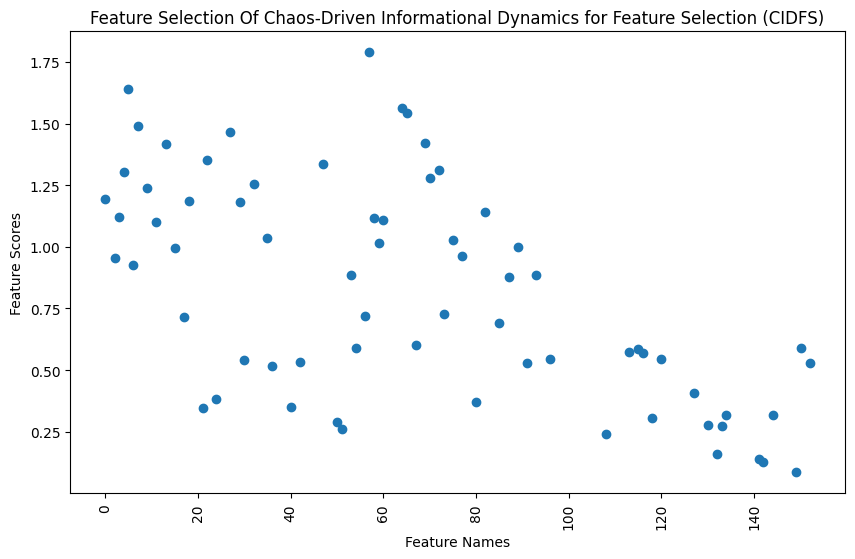

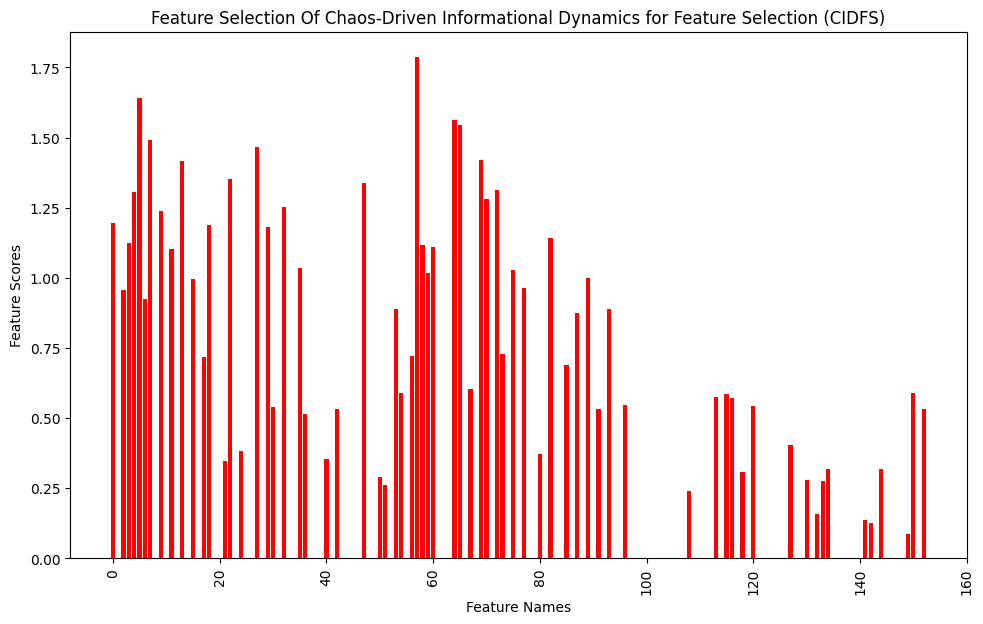

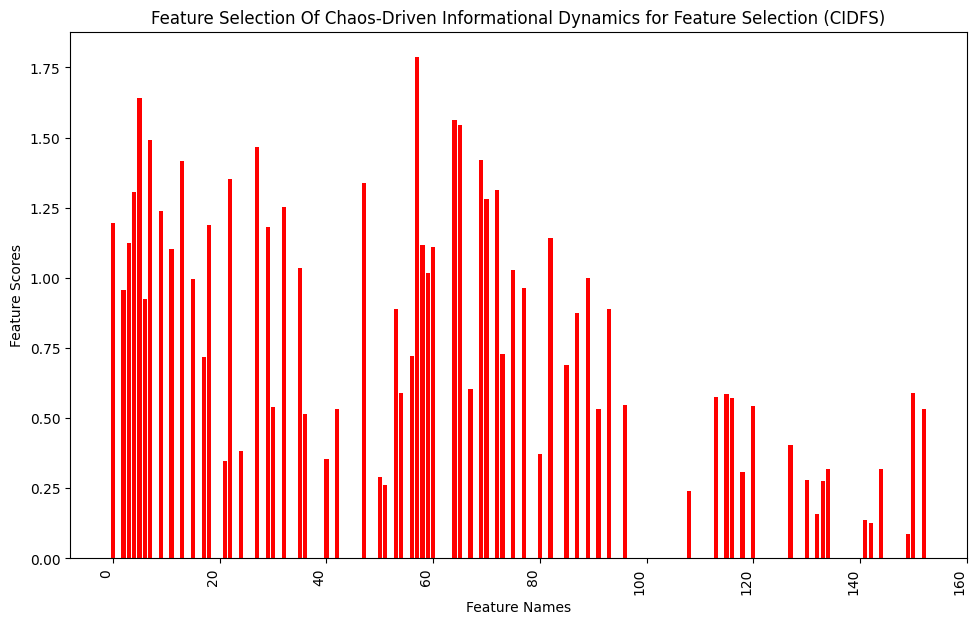

In [15]:

print(f"Before non-rediration {len(final_scores__)}: ",final_scores__)
final_scores = final_scores__[non_redundant_indices]


print(f"After non-rediration {len(final_scores)}: ",final_scores)

# Sort features by final score
# sorted_indices = final_scores #torch.argsort(final_scores, descending=True)
# # Select the indices of the top k features based on scores without sorting
# k = 70  # Number of top features to select
# threshold = torch.all(final_scores)# Determine the minimum score in the top k
# top_70_features = non_redundant_indices[final_scores >= threshold]  # Retain original order


# print("cont", len(sorted_indices))
sorted_features = non_redundant_indices
print("cont", len(sorted_features))

sorted_scores = final_scores

# Print all sorted features and scores
print("All features and their scores (sorted):")
for idx, score in zip(sorted_features, sorted_scores):
    print(f"Feature {idx.item()}: Score = {score.item()}")

# Select top 70 features
top_70_features = sorted_features
print("\nTop 70 features :")
for idx in top_70_features:
    print(f"Feature {idx.item()}: {data.columns[idx.item()]}")


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(sorted_features, sorted_scores)
# plt.bar(sorted_features,vae_scores)
plt.xlabel('Feature Names')
plt.ylabel('Feature Scores')
plt.title('Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS)')
plt.xticks(rotation=90)
plt.savefig(f"Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS)1.png")
plt.show()


plt.figure(figsize=(10,6))
# plt.scatter(sorted_features, vae_scores)
plt.bar(sorted_features,sorted_scores,color="red")
plt.xlabel('Feature Names')
plt.ylabel('Feature Scores')
plt.tight_layout()
plt.title('Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS)')
plt.xticks(rotation=90)
plt.show()


plt.figure(figsize=(10,6))
plt.bar(sorted_features,sorted_scores,color="red")
plt.xlabel('Feature Names')
plt.ylabel('Feature Scores')
plt.tight_layout()
plt.title('Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS)')
plt.xticks(rotation=90, ha='right')
plt.show()


In [16]:

data = pd.read_csv("Droidware2025.csv")
# Select top 70 features (retain original order)
# num_features_to_select = min(70, len(non_redundant_indices))
ds = data.drop(['Sha256','Label_x','Label_y'],axis=1)
top_70_features = non_redundant_indices

print(f"feature {len(top_70_features)} :",top_70_features)
print(f"before Score {len(final_scores)}", final_scores)
final_scores = sorted_scores
print("after score", final_scores)

selected_columns = ds.columns[top_70_features.numpy()].tolist()
selected_data = data[['Sha256']+selected_columns+['Label']]

# Save the selected features with Sha256
selected_data.to_csv("DroidWare.csv", index=False)
print("features saved to 'DroidWare.csv'.")



feature 68 : tensor([  0,   2,   3,   4,   5,   6,   7, 130,   9, 132,  11, 133,  13, 134,
         15, 141,  17,  18, 142, 144,  21,  22, 149,  24, 150, 152,  27,  29,
         30,  32,  35,  36,  40,  42,  47,  50,  51,  53,  54,  56,  57,  58,
         59,  60,  64,  65,  67,  69,  70,  72,  73,  75,  77,  80,  82,  85,
         87,  89,  91,  93,  96, 108, 113, 115, 116, 118, 120, 127])
before Score 68 tensor([1.1941, 0.9546, 1.1227, 1.3046, 1.6406, 0.9249, 1.4912, 0.2787, 1.2391,
        0.1585, 1.1025, 0.2743, 1.4167, 0.3171, 0.9948, 0.1377, 0.7174, 1.1870,
        0.1255, 0.3171, 0.3469, 1.3529, 0.0856, 0.3812, 0.5900, 0.5310, 1.4675,
        1.1815, 0.5405, 1.2537, 1.0340, 0.5159, 0.3520, 0.5337, 1.3366, 0.2910,
        0.2611, 0.8869, 0.5885, 0.7207, 1.7886, 1.1172, 1.0174, 1.1080, 1.5640,
        1.5447, 0.6028, 1.4207, 1.2800, 1.3126, 0.7272, 1.0280, 0.9625, 0.3723,
        1.1409, 0.6903, 0.8759, 0.9985, 0.5307, 0.8870, 0.5463, 0.2414, 0.5735,
        0.5869, 0.5702, 0.3068

count feature 68


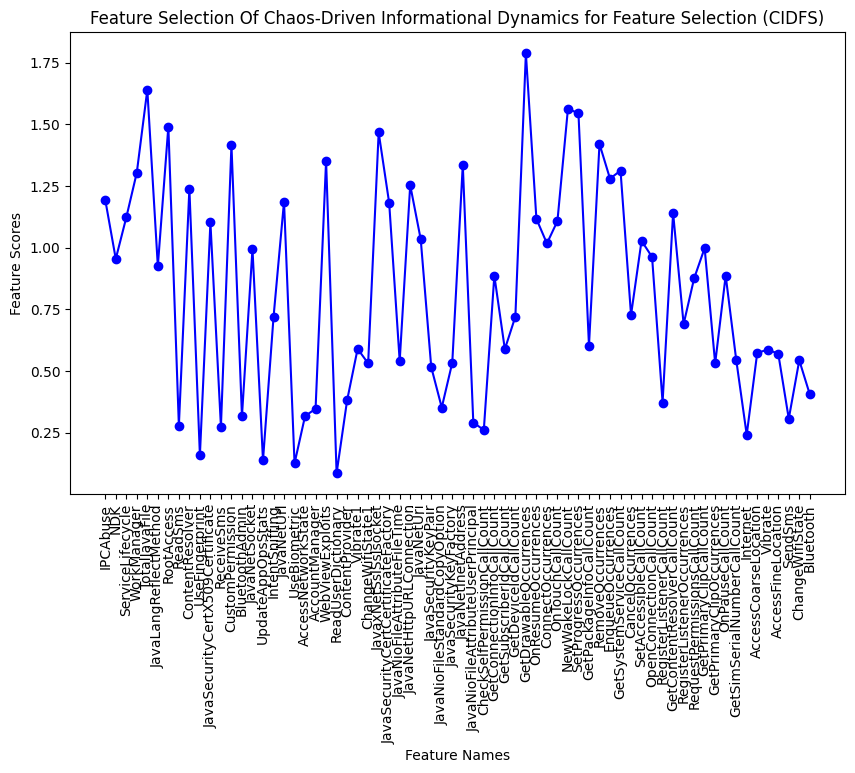

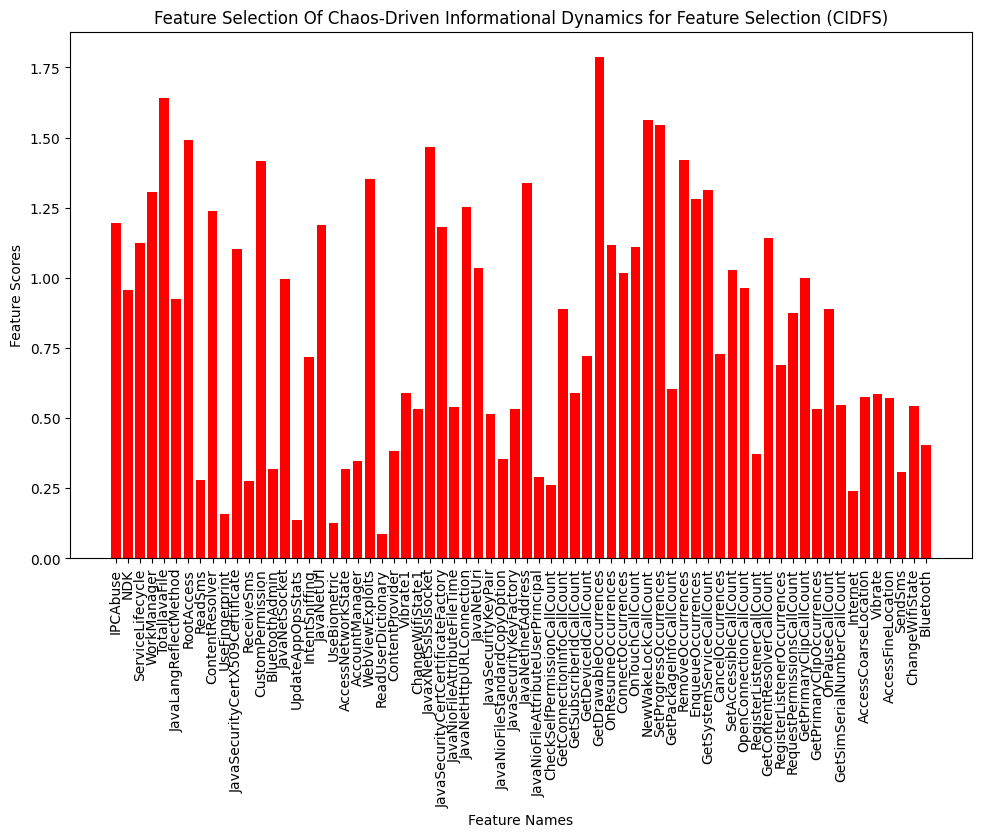

In [17]:

print("count feature",len(selected_columns))
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# plt.scatter(selected_columns, sorted_scores,linestyle='-')
# plt.bar(sorted_features,vae_scores)
# plt.grid(True)
plt.plot(selected_columns, sorted_scores, marker='o', linestyle='-', color='b')
   
plt.xlabel('Feature Names')
plt.ylabel('Feature Scores')
plt.title('Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS)')
plt.xticks(rotation=90)
plt.savefig("Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS).png")
plt.show()


plt.figure(figsize=(10,6))
# plt.scatter(sorted_features, vae_scores)
plt.bar(selected_columns,sorted_scores,color="red")
plt.xlabel('Feature Names')
plt.ylabel('Feature Scores')
plt.tight_layout()
plt.title('Feature Selection Of Chaos-Driven Informational Dynamics for Feature Selection (CIDFS)')
plt.xticks(rotation=90)
plt.show()


# plt.figure(figsize=(10,6))
# plt.bar(selected_columns,sorted_scores,color="red")
# plt.xlabel('Feature Names')
# plt.ylabel('Feature Scores')
# plt.tight_layout()
# plt.title('Feature Selection Of Custom Feature Selection')
# plt.xticks(rotation=90, ha='right')
# plt.show()